In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Dataset Information:

• The Titanic dataset contains 891 passenger records and 12 columns.
• Numerical columns include PassengerId, Survived, Pclass, Age, SibSp, Parch, and Fare.
• Categorical columns include Name, Sex, Ticket, Cabin, and Embarked.
• The Age column contains missing values (714 non-null values).
• The Cabin column contains a large number of missing values (204 non-null values).
• The Embarked column contains 2 missing values.

In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Statistical Summary:

• The dataset contains 891 passenger records.
• The average age of passengers is approximately 29.7 years.
• The youngest passenger was 0.42 years old and the oldest was 80 years old.
• The average fare paid was 32.20.
• The maximum fare paid was 512.33, indicating the presence of some high-value tickets.
• The average passenger class value is 2.31, showing that many passengers belonged to lower classes.

In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Missing Values Analysis:

• The Age column contains 177 missing values.
• The Cabin column contains 687 missing values.
• The Embarked column contains 2 missing values.
• All other columns contain complete data.
• Cabin has the highest number of missing values and may require special handling during analysis.

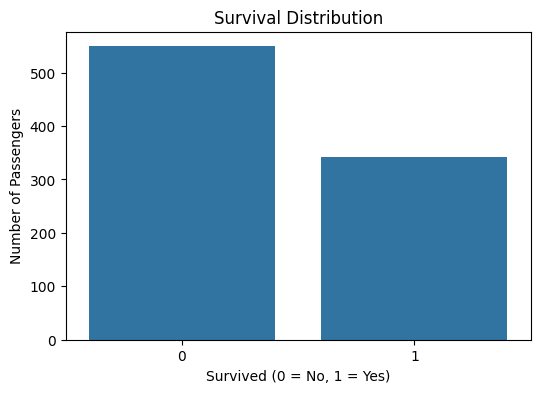

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)

plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

Survival Distribution Analysis:

• The number of passengers who did not survive was significantly higher than the number who survived.
• More than half of the passengers lost their lives in the disaster.
• The dataset shows an imbalanced survival distribution.

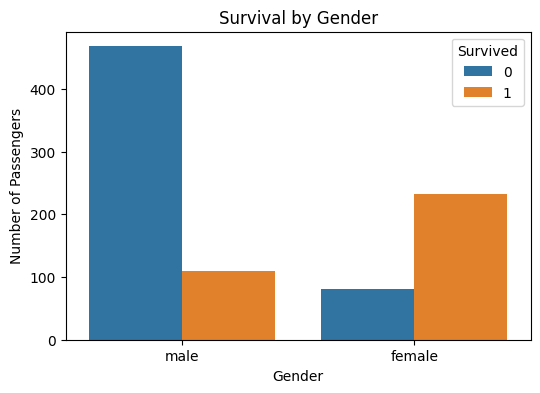

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

Survival by Gender Analysis:

• Female passengers had a much higher survival rate than male passengers.
• A large number of male passengers did not survive.
• More females survived than died, while the opposite trend was observed for males.
• Gender appears to have played a significant role in survival outcomes.

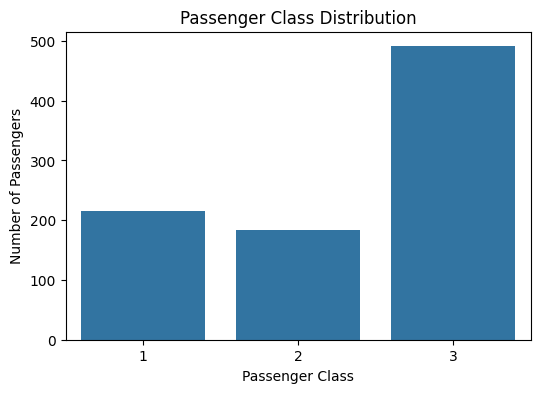

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x='Pclass', data=df)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

Passenger Class Distribution Analysis:

• Most passengers traveled in Third Class (Pclass 3).
• First Class and Second Class had significantly fewer passengers.
• Third Class accounted for more than half of the total passengers.
• The distribution indicates that the majority of passengers belonged to the lower travel class.

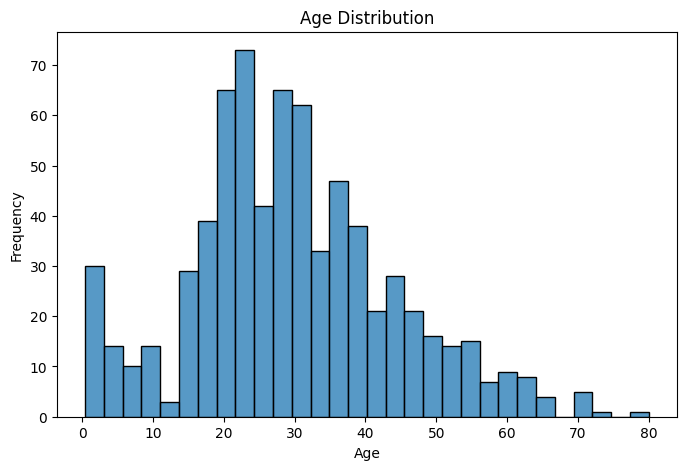

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'].dropna(), bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

Age Distribution Analysis:

• Most passengers were between 20 and 40 years old.
• The highest concentration of passengers was in their mid-20s.
• There were relatively few elderly passengers above 60 years of age.
• A small number of children were also present on board.
• The age distribution is slightly right-skewed, with fewer passengers at higher ages.

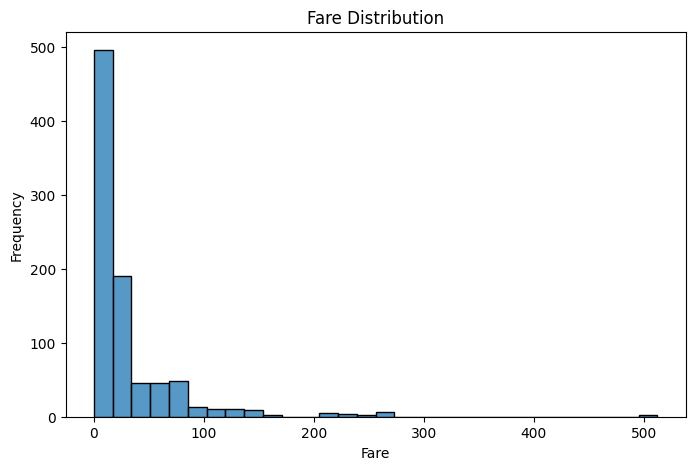

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['Fare'], bins=30)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

Fare Distribution Analysis:

• Most passengers paid relatively low fares.
• A small number of passengers paid very high fares.
• The fare distribution is highly right-skewed.
• The presence of extremely expensive tickets indicates outliers in the dataset.
• Most ticket fares are concentrated below 50.

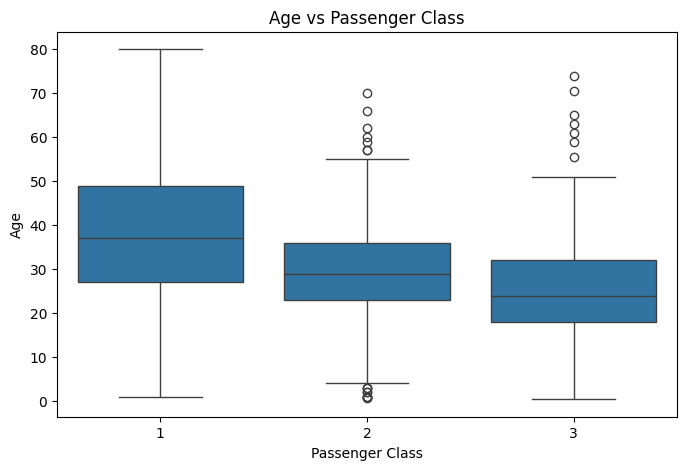

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Pclass', y='Age', data=df)

plt.title("Age vs Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")

plt.show()

Age vs Passenger Class Analysis:

• First Class passengers were generally older than passengers in other classes.
• Third Class passengers had the lowest median age.
• The age distribution varies across passenger classes.
• Several age outliers are visible in all classes, especially among older passengers.
• Passenger class appears to be associated with age.

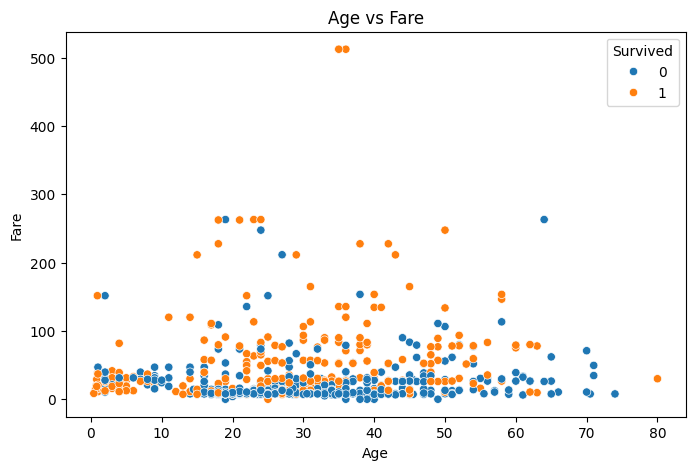

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

Age vs Fare Analysis:

• No strong linear relationship exists between age and fare.
• Most passengers paid lower fares regardless of age.
• Several high-fare outliers are visible in the dataset.
• Passengers who survived are more frequently observed among higher fare values.
• Fare appears to have had some influence on survival probability.

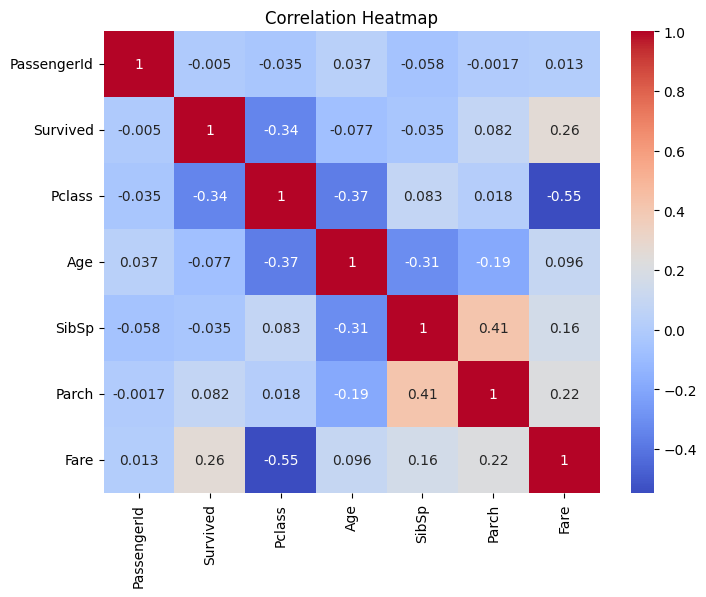

In [14]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

Correlation Heatmap Analysis:

• Passenger Class (Pclass) and Fare have a strong negative correlation (-0.55).
• Survival has a moderate positive correlation with Fare (0.26).
• Survival has a negative correlation with Passenger Class (-0.34).
• SibSp and Parch show a moderate positive correlation (0.41).
• Most variables have weak correlations with each other.
• Passenger Class and Fare appear to be the most strongly related variables in the dataset.

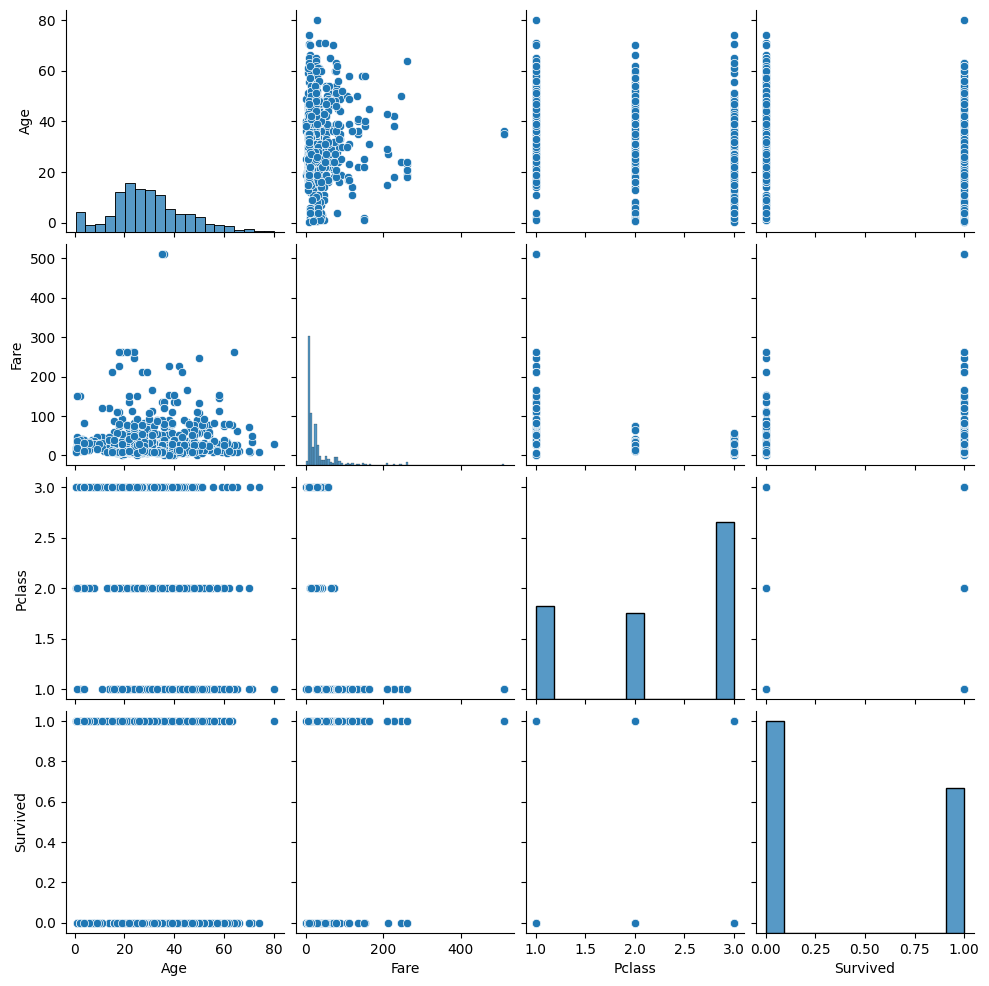

In [15]:
sns.pairplot(
    df[['Age', 'Fare', 'Pclass', 'Survived']].dropna()
)

plt.show()

# Final Findings Summary

1. The Titanic dataset contains 891 passenger records and 12 features.

2. Missing values were found in the Age, Cabin, and Embarked columns, with Cabin containing the highest number of missing values.

3. More passengers died than survived during the disaster.

4. Female passengers had a significantly higher survival rate compared to male passengers.

5. Most passengers traveled in Third Class, indicating that the majority belonged to lower travel classes.

6. The majority of passengers were between 20 and 40 years old.

7. Ticket fares were highly skewed, with most passengers paying low fares and a few passengers paying extremely high fares.

8. First Class passengers were generally older than passengers in Second and Third Class.

9. Fare and Passenger Class showed a strong relationship, with higher-class passengers typically paying higher fares.

10. Survival was influenced by factors such as gender, passenger class, and fare.

11. Correlation analysis showed that Passenger Class and Fare had the strongest relationship among the numerical variables.

12. Exploratory Data Analysis helped identify patterns, trends, and relationships within the Titanic dataset.

# Conclusion

The Exploratory Data Analysis of the Titanic dataset revealed several important patterns related to passenger survival. Gender, passenger class, and fare were found to be influential factors in determining survival outcomes. Female passengers and higher-class travelers had better chances of survival. The analysis also highlighted missing values, outliers, and relationships among variables. Overall, EDA provided valuable insights into the dataset and demonstrated the importance of data visualization and statistical exploration in understanding real-world data.